In [154]:
%pip install -q pandas numpy matplotlib seaborn

In [155]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the Dataset

In [156]:
df=pd.read_csv("Salary_Data.csv")

In [157]:
df.head()

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0


# Label Encoding

In [158]:
from sklearn.preprocessing import LabelEncoder

# Create separate encoders
le_mainroad = LabelEncoder()
le_guestroom = LabelEncoder()
le_basement = LabelEncoder()

# Apply encoding
df["Gender"] = le_mainroad.fit_transform(df["Gender"])
df["Education Level"] = le_guestroom.fit_transform(df["Education Level"])
df["Job Title"] = le_basement.fit_transform(df["Job Title"])


In [159]:
df.head()

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,1,0,177,5.0,90000.0
1,28.0,0,3,18,3.0,65000.0
2,45.0,1,5,145,15.0,150000.0
3,36.0,0,0,116,7.0,60000.0
4,52.0,1,3,26,20.0,200000.0


In [160]:
# Check mising values
df.isnull().sum()

,0
Age,2
Gender,0
Education Level,0
Job Title,0
Years of Experience,3
Salary,5


# Filling Missing Values by Mean

In [161]:
df['Years of Experience'].fillna(df['Years of Experience'].mean(), inplace=True)
df['Age'].fillna(df['Age'].mean(), inplace=True)
df['Salary'].fillna(df['Salary'].mean(), inplace=True)

/tmp/ipykernel_3851/2031456937.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Years of Experience'].fillna(df['Years of Experience'].mean(), inplace=True)
/tmp/ipykernel_3851/2031456937.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].me

In [162]:
# Check mising values
df.isnull().sum()

,0
Age,0
Gender,0
Education Level,0
Job Title,0
Years of Experience,0
Salary,0


In [163]:
# Features (all except 'price')
X = df.drop(["Salary"], axis=1)

# Target variable
y = df["Salary"]

In [164]:
# Linear Regression for House Price Prediction
from sklearn.model_selection import train_test_split

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Training Linear Regression for Comparison

In [165]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

y_pred_lin = lin_reg.predict(X_test)

lin_r2 = r2_score(y_test, y_pred_lin)
lin_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lin))

print("Linear Regression -> R2:", lin_r2, " RMSE:", lin_rmse)

Linear Regression -> R2: 0.6656315918797494  RMSE: 29883.00972541149


# **Polynomial Regression**
extends linear regression by adding powers of the input feature(s) as new terms, letting the model fit curved (non-linear) relationships instead of just a straight line. It's still "linear" in the coefficients — only the features are transformed.

$$
y = \beta_0 + \beta_1 x + \beta_2 x^2 + \beta_3 x^3 + \dots + \beta_n x^n + \epsilon
$$

In [166]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

poly_reg = LinearRegression()
poly_reg.fit(X_train_poly, y_train)

y_pred_poly = poly_reg.predict(X_test_poly)

poly_r2 = r2_score(y_test, y_pred_poly)
poly_rmse = np.sqrt(mean_squared_error(y_test, y_pred_poly))

print("Polynomial Regression (deg=2) -> R2:", poly_r2, " RMSE:", poly_rmse)

Polynomial Regression (deg=2) -> R2: 0.8277754948110898  RMSE: 21446.636462035513


In [167]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Polynomial Regression (deg=2)"],
    "R2 Score": [lin_r2, poly_r2],
    "RMSE": [lin_rmse, poly_rmse]
})
results

,Model,R2 Score,RMSE
0,Linear Regression,0.665632,29883.009725
1,Polynomial Regression (deg=2),0.827775,21446.636462


In [168]:
# Use Years of Experience as the x-axis since it's usually the strongest predictor
feature_col = 'Years of Experience'

# Build a dataframe combining test features, actual, and predicted values
plot_df = X_test.copy()
plot_df['Actual'] = y_test.values
plot_df['Pred_Linear'] = y_pred_lin
plot_df['Pred_Poly'] = y_pred_poly

# Sort by the chosen feature so lines look clean instead of jumping around
plot_df = plot_df.sort_values(by=feature_col)

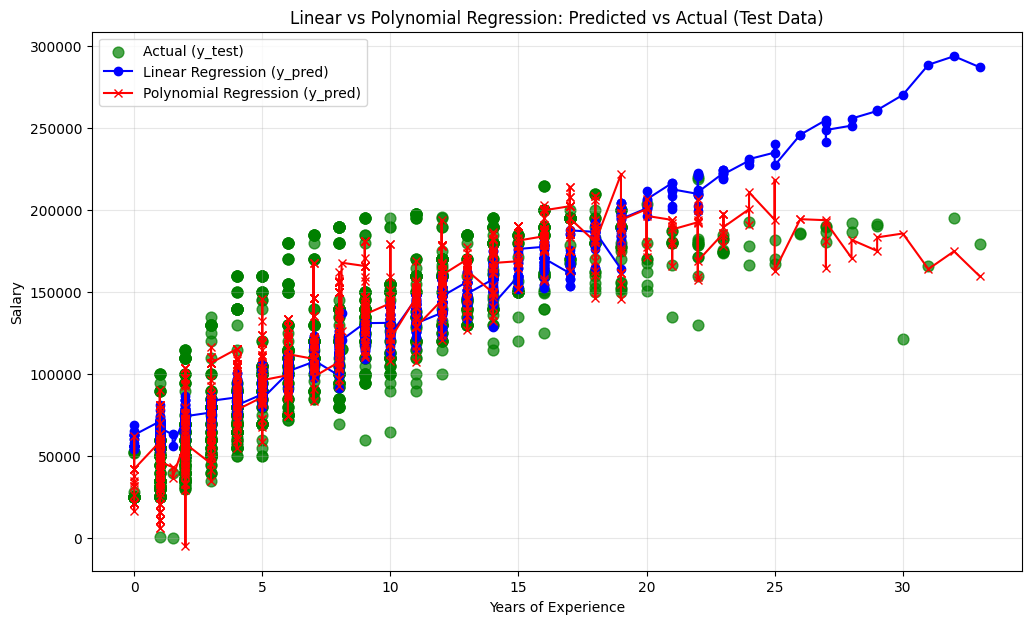

In [169]:
plt.figure(figsize=(12, 7))

# Actual test points
plt.scatter(plot_df[feature_col], plot_df['Actual'],
            color='green', label='Actual (y_test)', alpha=0.7, s=60)

# Linear regression predictions
plt.plot(plot_df[feature_col], plot_df['Pred_Linear'],
          color='blue', linestyle='-', marker='o', label='Linear Regression (y_pred)')

# Polynomial regression predictions
plt.plot(plot_df[feature_col], plot_df['Pred_Poly'],
          color='red', linestyle='-', marker='x', label='Polynomial Regression (y_pred)')

plt.xlabel(feature_col)
plt.ylabel("Salary")
plt.title("Linear vs Polynomial Regression: Predicted vs Actual (Test Data)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

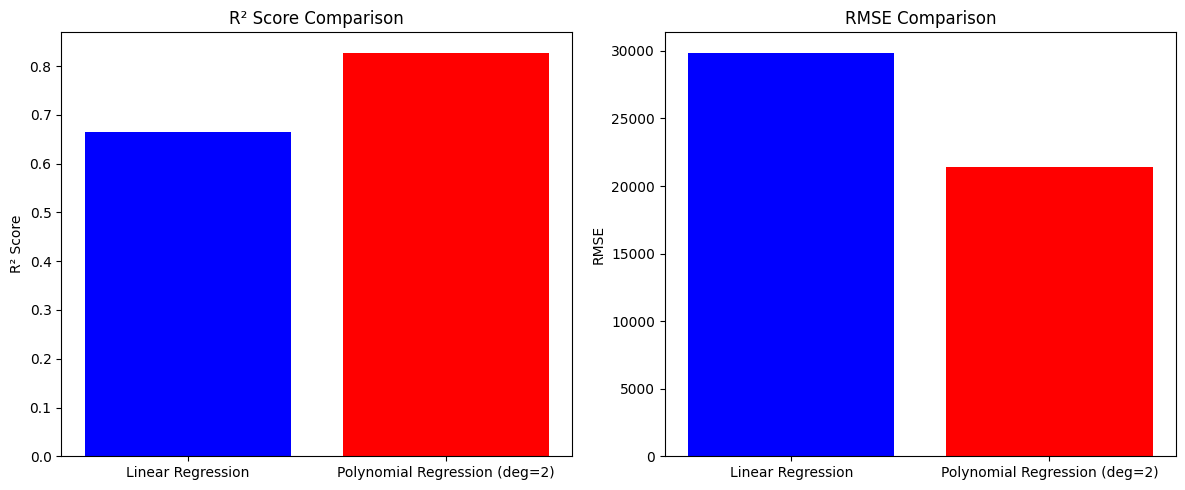

In [170]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(results["Model"], results["R2 Score"], color=['blue', 'red'])
axes[0].set_title("R² Score Comparison")
axes[0].set_ylabel("R² Score")

axes[1].bar(results["Model"], results["RMSE"], color=['blue', 'red'])
axes[1].set_title("RMSE Comparison")
axes[1].set_ylabel("RMSE")

plt.tight_layout()
plt.show()